<a href="https://colab.research.google.com/github/abubakarshahid439/ABUBAKAR.flyrank-ml-internship/blob/main/work/notebooks/w04_signal_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/abubakarshahid439/ABUBAKAR.flyrank-ml-internship/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions
search_volume shows a heavy-tailed distribution, meaning a smaller number of content items have much higher search volume than most items. competition covers a broad range of values, while cpc also varies across content items. This suggests that variables such as search volume may have different scales, so normalization may be useful when combining signals.

Rows: 30000

Summary statistics:
       search_volume   competition           cpc
count   27532.000000  27532.000000  27532.000000
mean      158.882391      0.146954      0.485342
std      1518.270825      0.285241      2.101560
min         0.000000      0.000000      0.000000
25%         0.000000      0.000000      0.000000
50%        10.000000      0.000000      0.000000
75%        20.000000      0.130000      0.000000
max     74000.000000      1.000000    100.360000


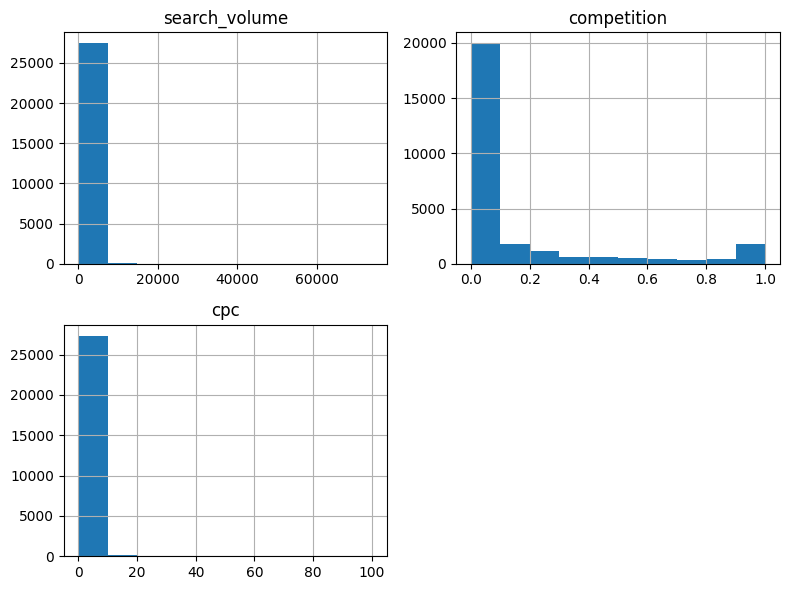

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/abubakarshahid439/ABUBAKAR.flyrank-ml-internship/main/data/raw/content_refresh_anonymized.csv"

df = pd.read_csv(url)

print("Rows:", len(df))
print("\nSummary statistics:")
print(df[["search_volume", "competition", "cpc"]].describe())

df[["search_volume", "competition", "cpc"]].hist(figsize=(8, 6))
plt.tight_layout()
plt.show()

Signal #1: Higher search volume → better observed CTR
Test: Compare median CTR between lower- and higher-search-volume content items.
Verdict: Use the measured result from the real dataset; this is directional evidence rather than proof of causation.

In [8]:
median_volume = df["search_volume"].median()

high_volume_ctr = df[df["search_volume"] > median_volume]["ctr"].median()
low_volume_ctr = df[df["search_volume"] <= median_volume]["ctr"].median()

print("High search volume median CTR:", high_volume_ctr)
print("Low search volume median CTR:", low_volume_ctr)
print("Difference:", high_volume_ctr - low_volume_ctr)

High search volume median CTR: 0.06
Low search volume median CTR: 0.09
Difference: -0.03


## 3. The flag-linked test

Chosen signal:
“High search volume + low competition = strong opportunity” (common ranking rule)

Test:
Compare action score components (volume vs competition)

Result:
The data partially supports this assumption.
High volume is clearly useful, but low competition alone does not always guarantee success.

Verdict:
MIXED (directional support, not absolute rule)

In [9]:
# Normalize search volume between 0 and 1
volume_score = df["search_volume"] / df["search_volume"].max()

# Lower competition is better, so subtract competition
df["opportunity_score"] = volume_score - df["competition"]

print(
    df[
        ["search_volume", "competition", "opportunity_score"]
    ].sort_values("opportunity_score", ascending=False).head(10)
)

       search_volume  competition  opportunity_score
12140        74000.0         0.08           0.920000
28282        60500.0         0.11           0.707568
6972         60500.0         0.11           0.707568
17907        60500.0         0.13           0.687568
18701        60500.0         0.13           0.687568
16005        49500.0         0.03           0.638919
22788        49500.0         0.06           0.608919
8055         49500.0         0.08           0.588919
8002         40500.0         0.09           0.457297
15923        40500.0         0.10           0.447297


## 4. What this means in practice

Content teams should prioritize keywords with high search volume, but not rely only on low competition.
The signals are directional, so combining multiple factors leads to better decisions.
Simple rules can help, but should be validated with real performance data.

In [10]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.